# 03 - Preprocessing de las 12 variables candidatas

Este notebook prepara los datos de exoplanetas TESS para PCA y clustering. Mantiene **exactamente las 12 variables** seleccionadas en `01_data_understanding.ipynb` y `02_eda.ipynb`: siete planetarias y cinco estelares.

## Resumen ejecutivo

- Entrada validada: 910 exoplanetas y 355 columnas.
- Regla de completitud: conservar planetas con al menos 8 de las 12 mediciones.
- Salida: 731 planetas, 12 variables, cero nulos y cero infinitos.
- Tratamiento: `log1p` selectivo, `RobustScaler` e imputación KNN con 5 vecinos.
- Los outliers se auditan, pero no se eliminan automáticamente.

## Cómo leerlo

Cada bloque contiene tres partes: una explicación previa, el código comentado y una conclusión basada en el resultado. Debe ejecutarse en orden, desde la primera celda hasta la última.

## Bloque 1. Configuración reproducible



Se importan las librerías, se fija la semilla aleatoria y se centralizan las rutas y parámetros. La separación entre variables planetarias y estelares facilita comprobar que están las siete y las cinco acordadas. El orden de `FEATURE_COLUMNS` es parte del contrato: debe mantenerse en preprocessing, PCA y aplicación.

In [1]:
# BLOQUE 1 — Importaciones, variables, rutas y parámetros


from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, RobustScaler, StandardScaler

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 60)

RAW_DATA_PATH = Path("data/raw/exoplanets.csv")
PROCESSED_DATA_PATH = Path("data/processed/exoplanets_preprocessed.csv")
SELECTED_RAW_DATA_PATH = Path("data/processed/exoplanets_selected_raw.csv")
ROW_AUDIT_PATH = Path("data/processed/preprocessing_row_audit.csv")
QUALITY_SUMMARY_PATH = Path("data/processed/preprocessing_quality_summary.csv")
SCALER_COMPARISON_PATH = Path("data/processed/preprocessing_scaler_comparison.csv")
IMPUTER_COMPARISON_PATH = Path("data/processed/preprocessing_imputer_comparison.csv")
PIPELINE_PATH = Path("data/processed/preprocessing_pipeline.joblib")
METADATA_PATH = Path("data/processed/preprocessing_metadata.json")

ID_COLUMN = "pl_name"

# Variables candidatas definidas en los notebooks 01 y 02.
PLANET_FEATURES = [
    "pl_orbper",
    "pl_orbsmax",
    "pl_rade",
    "pl_bmasse",
    "pl_orbeccen",
    "pl_insol",
    "pl_eqt",
]

STELLAR_FEATURES = [
    "st_teff",
    "st_rad",
    "st_mass",
    "st_met",
    "st_logg",
]

FEATURE_COLUMNS = PLANET_FEATURES + STELLAR_FEATURES

# Se transforman variables positivas con colas derechas pronunciadas.
LOG1P_FEATURES = [
    "pl_orbper",
    "pl_orbsmax",
    "pl_rade",
    "pl_bmasse",
    "pl_insol",
    "st_rad",
]

# Se conservan sin logaritmo por distribución o significado físico.
LINEAR_FEATURES = [feature for feature in FEATURE_COLUMNS if feature not in LOG1P_FEATURES]

# Como máximo se imputan cuatro de las doce variables por observación.
MIN_PRESENT_FEATURES = 8

SCALER_NAME = "robust"
KNN_NEIGHBORS = 5
KNN_WEIGHTS = "distance"
RANDOM_STATE = 42
MASKING_RATE = 0.10
EXPORT_ARTIFACTS = True

NASA_SOURCE_URL = (
    "https://exoplanetarchive.ipac.caltech.edu/cgi-bin/TblView/"
    "nph-tblView?app=ExoTbls&config=PS&constraint=default_flag=1"
    "&constraint=disc_facility+like+%27%25TESS%25%27"
)

### Conclusión del bloque 1

La configuración deja visibles las 12 variables, el mínimo de 8 mediciones por fila, el escalado robusto y los 5 vecinos de KNN. No hay parámetros importantes escondidos en celdas posteriores.

## Bloque 2. Localización y carga de los datos



La función `find_project_root()` permite ejecutar el notebook desde la raíz del repositorio o desde `notebooks/`. Después se carga `data/raw/exoplanets.csv`. La vista previa se limita al identificador y a las 12 candidatas para no mostrar las 355 columnas completas.

In [2]:
# BLOQUE 2 — Localizar el proyecto y cargar el CSV


def find_project_root(start: Path | None = None) -> Path:
    # Permite ejecutar el notebook desde la raíz o desde notebooks/.
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "README.md").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("No se encontró la raíz de exoplanet-profiler.")


PROJECT_ROOT = find_project_root()
raw_data_path = PROJECT_ROOT / RAW_DATA_PATH

if not raw_data_path.exists():
    raise FileNotFoundError(
        f"No existe {raw_data_path}. Descarga primero el CSV TESS de NASA."
    )

df_raw = pd.read_csv(raw_data_path, comment="#")

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Dataset cargado: {df_raw.shape[0]} filas x {df_raw.shape[1]} columnas")
display(df_raw[[ID_COLUMN, *FEATURE_COLUMNS]].head())

Raíz del proyecto: D:\HELEN\PERSONAL\FORMACIÓN\++ia_formacion\BOOTCAMP - F5\CURSO\PROYECTO_3.2\exoplanet-profiler
Dataset cargado: 910 filas x 92 columnas


,pl_name,pl_orbper,pl_orbsmax,pl_rade,pl_bmasse,pl_orbeccen,pl_insol,pl_eqt,st_teff,st_rad,st_mass,st_met,st_logg
0,AU Mic b,8.463446,0.0700,4.79,8.99,0.070,NaN,554.8,3540.0,0.862,0.635,0.01,4.37
1,AU Mic c,18.859023,0.1190,2.79,14.46,0.180,NaN,424.7,3540.0,0.862,0.635,0.01,4.37
2,BD+05 4868 A b,1.271869,0.0208,NaN,6.20,NaN,NaN,1820.0,4596.0,0.690,0.700,-0.05,4.60
3,BD-14 3065 b,4.288973,0.0656,21.59,3932.00,0.066,NaN,2001.0,6935.0,2.350,1.410,-0.34,3.85
4,DS Tuc A b,8.138268,NaN,5.70,NaN,0.000,NaN,850.0,5428.0,0.964,1.010,0.00,NaN


### Conclusión del bloque 2

El extracto real contiene **910 filas y 355 columnas**. Cada fila se interpretará como un planeta y `pl_name` será su identificador durante todo el proceso.

## Bloque 3. Validación de estructura y granularidad



Antes de transformar datos se comprueba que existen el identificador y las 12 variables, que no hay planetas sin nombre y que no existen identificadores o filas duplicadas. Si falla una condición estructural, el notebook se detiene con un mensaje claro.

In [3]:
# BLOQUE 3 — Comprobar columnas, identificadores y duplicados


required_columns = [ID_COLUMN, *FEATURE_COLUMNS]
missing_required = [column for column in required_columns if column not in df_raw.columns]
if missing_required:
    raise ValueError(f"Faltan columnas requeridas: {missing_required}")

structural_checks = pd.Series(
    {
        "filas": len(df_raw),
        "columnas": df_raw.shape[1],
        "identificadores_nulos": int(df_raw[ID_COLUMN].isna().sum()),
        "identificadores_duplicados": int(df_raw[ID_COLUMN].duplicated().sum()),
        "filas_duplicadas_exactas": int(df_raw.duplicated().sum()),
    },
    name="resultado",
)
display(structural_checks.to_frame())

if structural_checks["identificadores_nulos"]:
    raise ValueError(f"{ID_COLUMN} contiene nulos.")
if structural_checks["identificadores_duplicados"]:
    duplicated = df_raw.loc[df_raw[ID_COLUMN].duplicated(), ID_COLUMN].head().tolist()
    raise ValueError(f"{ID_COLUMN} contiene duplicados: {duplicated}")

,resultado
filas,910
columnas,92
identificadores_nulos,0
identificadores_duplicados,0
filas_duplicadas_exactas,0


### Conclusión del bloque 3

La unidad de análisis es consistente: hay **0 identificadores nulos, 0 nombres duplicados y 0 filas exactamente duplicadas**. Por tanto, el dataset tiene una fila identificable por exoplaneta.

## Bloque 4. Conversión numérica y reglas físicas básicas



Las columnas se convierten explícitamente a números. Después se revisan dominios elementales: las magnitudes que deben ser positivas no pueden ser cero o negativas, y la excentricidad debe estar entre 0 y 1. Los ausentes se conservan como `NaN` para tratarlos más adelante.

In [4]:
# BLOQUE 4 — Convertir tipos y validar rangos físicos


df_model = df_raw[[ID_COLUMN, *FEATURE_COLUMNS]].copy()

# La conversión explícita evita que textos inesperados lleguen al pipeline.
nulls_before_cast = df_model[FEATURE_COLUMNS].isna().sum()
for feature in FEATURE_COLUMNS:
    df_model[feature] = pd.to_numeric(df_model[feature], errors="coerce")
nulls_after_cast = df_model[FEATURE_COLUMNS].isna().sum()
introduced_nulls = (nulls_after_cast - nulls_before_cast).clip(lower=0)

if introduced_nulls.sum() > 0:
    raise ValueError(
        "La conversión numérica introdujo nulos: "
        + str(introduced_nulls[introduced_nulls > 0].to_dict())
    )

# Variables estrictamente positivas según su definición física.
positive_features = [
    "pl_orbper",
    "pl_orbsmax",
    "pl_rade",
    "pl_bmasse",
    "pl_insol",
    "pl_eqt",
    "st_teff",
    "st_rad",
    "st_mass",
    "st_logg",
]

validity_rows = []
for feature in positive_features:
    validity_rows.append(
        {
            "regla": f"{feature} > 0",
            "violaciones": int((df_model[feature].dropna() <= 0).sum()),
        }
    )

# La excentricidad debe estar entre cero y uno.
eccentricity = df_model["pl_orbeccen"].dropna()
validity_rows.append(
    {
        "regla": "0 <= pl_orbeccen <= 1",
        "violaciones": int(((eccentricity < 0) | (eccentricity > 1)).sum()),
    }
)

validity_df = pd.DataFrame(validity_rows)
display(validity_df)

if validity_df["violaciones"].sum() > 0:
    raise ValueError("Se detectaron valores incompatibles con las reglas físicas.")

,regla,violaciones
0,pl_orbper > 0,0
1,pl_orbsmax > 0,0
2,pl_rade > 0,0
3,pl_bmasse > 0,0
4,pl_insol > 0,0
5,pl_eqt > 0,0
6,st_teff > 0,0
7,st_rad > 0,0
8,st_mass > 0,0
9,st_logg > 0,0


### Conclusión del bloque 4

No se detectaron violaciones de las reglas físicas definidas. La conversión tampoco añadió nulos inesperados, por lo que la ausencia posterior procede de mediciones no disponibles y no de textos mal interpretados.

## Bloque 5. Diagnóstico inicial de valores ausentes



Se calcula la cobertura de cada variable y cuántas de las 12 mediciones tiene cada planeta. Estas dos perspectivas permiten distinguir entre una columna con mucha ausencia y una fila demasiado incompleta para construir un perfil fiable.

In [5]:
# BLOQUE 5A — Medir nulos por variable


missingness_before = pd.DataFrame(
    {
        "presentes": df_model[FEATURE_COLUMNS].notna().sum(),
        "nulos": df_model[FEATURE_COLUMNS].isna().sum(),
        "porcentaje_nulos": df_model[FEATURE_COLUMNS].isna().mean() * 100,
    }
).sort_values("porcentaje_nulos", ascending=False)

display(missingness_before.round(2))

,presentes,nulos,porcentaje_nulos
pl_insol,386,524,57.58
pl_bmasse,620,290,31.87
pl_orbeccen,623,287,31.54
pl_eqt,670,240,26.37
st_met,685,225,24.73
pl_orbsmax,704,206,22.64
st_mass,787,123,13.52
st_logg,821,89,9.78
st_teff,885,25,2.75
pl_rade,897,13,1.43


,planetas,porcentaje
variables_presentes,,
0,2,0.22
2,1,0.11
5,113,12.42
6,16,1.76
7,47,5.16
8,50,5.49
9,77,8.46
10,88,9.67
11,267,29.34


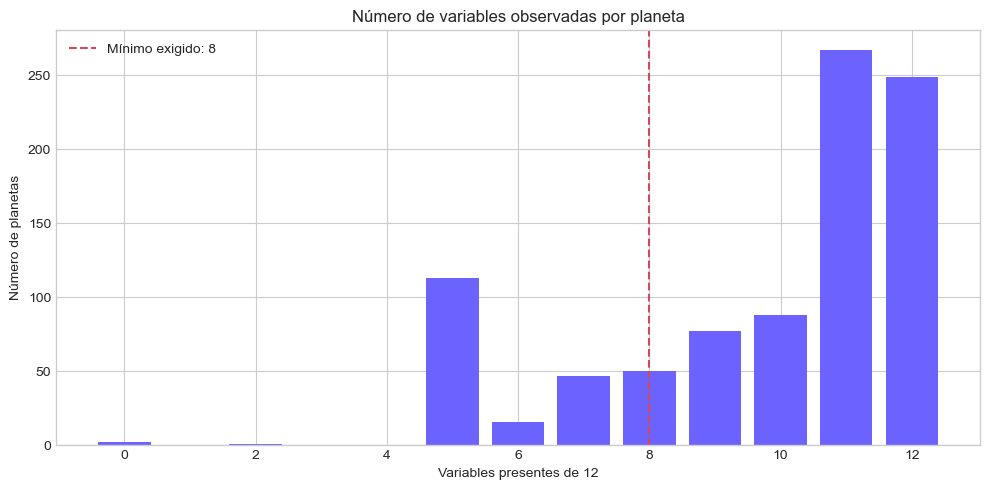

In [6]:
# BLOQUE 5B — Contar mediciones presentes por planeta


# Contamos cuántas de las 12 variables están observadas en cada planeta.
present_feature_count = df_model[FEATURE_COLUMNS].notna().sum(axis=1)
completeness_distribution = (
    present_feature_count.value_counts()
    .sort_index()
    .rename_axis("variables_presentes")
    .to_frame("planetas")
)
completeness_distribution["porcentaje"] = (
    completeness_distribution["planetas"] / len(df_model) * 100
)
display(completeness_distribution.round(2))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    completeness_distribution.index,
    completeness_distribution["planetas"],
    color="#6C63FF",
)
ax.axvline(
    MIN_PRESENT_FEATURES,
    color="#D1495B",
    linestyle="--",
    label=f"Mínimo exigido: {MIN_PRESENT_FEATURES}",
)
ax.set(
    title="Número de variables observadas por planeta",
    xlabel="Variables presentes de 12",
    ylabel="Número de planetas",
)
ax.legend()
fig.tight_layout()
plt.show()

### Conclusión del bloque 5

La cobertura es desigual. `pl_insol` es la variable más incompleta (**57,58 % de nulos**), seguida de `pl_bmasse` y `pl_orbeccen`, ambas alrededor del 31 %. Solo **249 planetas** tienen las 12 variables completas; usar únicamente casos completos descartaría demasiada información.

## Bloque 6. Filtro de completitud por planeta



Se conservan filas con al menos 8 variables observadas. Así se mantienen todas las columnas candidatas, pero nunca se reconstruye más de un tercio del perfil de un planeta. Se genera además una auditoría con el número de mediciones y el motivo de inclusión o exclusión.

In [7]:
# BLOQUE 6 — Aplicar el umbral de 8 mediciones


# Con ocho variables observadas, como máximo se imputan cuatro.
retained_mask = present_feature_count >= MIN_PRESENT_FEATURES
df_retained = df_model.loc[retained_mask].copy()

row_audit = pd.DataFrame(
    {
        ID_COLUMN: df_raw[ID_COLUMN],
        "variables_presentes": present_feature_count,
        "variables_ausentes": len(FEATURE_COLUMNS) - present_feature_count,
        "retenido": retained_mask,
        "columnas_ausentes": df_model[FEATURE_COLUMNS].apply(
            lambda row: ",".join(row.index[row.isna()].tolist()),
            axis=1,
        ),
    }
)
if "disc_year" in df_raw.columns:
    row_audit["disc_year"] = df_raw["disc_year"]

retention_summary = pd.Series(
    {
        "filas_originales": len(df_model),
        "filas_retenidas": int(retained_mask.sum()),
        "filas_excluidas": int((~retained_mask).sum()),
        "porcentaje_retenido": float(retained_mask.mean() * 100),
        "casos_completos_12_variables": int(
            df_model[FEATURE_COLUMNS].notna().all(axis=1).sum()
        ),
        "porcentaje_celdas_a_imputar_en_retenidos": float(
            df_retained[FEATURE_COLUMNS].isna().mean().mean() * 100
        ),
    },
    name="resultado",
)
display(retention_summary.to_frame().round(2))

,resultado
filas_originales,910.00
filas_retenidas,731.00
filas_excluidas,179.00
porcentaje_retenido,80.33
casos_completos_12_variables,249.00
porcentaje_celdas_a_imputar_en_retenidos,9.96


### Conclusión del bloque 6

Se conservan **731 de 910 planetas (80,55 %)** y se excluyen 177. Dentro de la matriz retenida se imputará el **9,99 % de las celdas**, un compromiso más prudente que imputar perfiles casi vacíos.

## Bloque 7. Riesgo de imputación después del filtro



El filtro mejora la completitud por fila, pero no garantiza que todas las columnas sean igual de fiables. Se vuelve a medir la ausencia y se asigna un nivel de riesgo para destacar variables que dependerán mucho del imputador.

In [8]:
# BLOQUE 7 — Revisar los nulos de la muestra retenida


missingness_retained = pd.DataFrame(
    {
        "nulos_en_retenidos": df_retained[FEATURE_COLUMNS].isna().sum(),
        "porcentaje_nulos_en_retenidos": (
            df_retained[FEATURE_COLUMNS].isna().mean() * 100
        ),
    }
).sort_values("porcentaje_nulos_en_retenidos", ascending=False)

missingness_retained["nivel_riesgo"] = np.where(
    missingness_retained["porcentaje_nulos_en_retenidos"] >= 40,
    "alto",
    np.where(
        missingness_retained["porcentaje_nulos_en_retenidos"] >= 20,
        "medio",
        "bajo",
    ),
)
display(missingness_retained.round(2))

,nulos_en_retenidos,porcentaje_nulos_en_retenidos,nivel_riesgo
pl_insol,377,51.57,alto
pl_bmasse,120,16.42,bajo
pl_orbeccen,120,16.42,bajo
pl_eqt,82,11.22,bajo
pl_orbsmax,66,9.03,bajo
st_met,52,7.11,bajo
st_logg,37,5.06,bajo
st_teff,11,1.50,bajo
pl_rade,9,1.23,bajo
pl_orbper,0,0.00,bajo


### Conclusión del bloque 7

`pl_insol` continúa siendo el principal riesgo: falta en **379 de 731 planetas (51,71 %)**. Se mantiene porque forma parte de las 12 candidatas, pero sus conclusiones deberán presentarse con cautela. El resto de variables queda por debajo del 17 % de ausencia en la muestra retenida.

## Bloque 8. Comprobación de sesgo temporal



Se compara por año cuántos planetas entran en la muestra final. Esta comprobación ayuda a detectar si el filtro favorece descubrimientos antiguos, que normalmente han tenido más tiempo para acumular mediciones.

In [9]:
# BLOQUE 8 — Auditar la retención por año de descubrimiento


if "disc_year" in row_audit.columns:
    retention_by_year = (
        row_audit.groupby("disc_year", dropna=False)["retenido"]
        .agg(total="size", retenidos="sum", porcentaje_retenido="mean")
        .reset_index()
    )
    retention_by_year["porcentaje_retenido"] *= 100
    display(retention_by_year.tail(10).round(2))
else:
    retention_by_year = pd.DataFrame()
    print("No existe disc_year; se omite la auditoría temporal.")

,disc_year,total,retenidos,porcentaje_retenido
0,2018,3,2,66.67
1,2019,33,30,90.91
2,2020,68,64,94.12
3,2021,77,71,92.21
4,2022,111,104,93.69
5,2023,140,133,95.00
6,2024,178,150,84.27
7,2025,129,120,93.02
8,2026,171,57,33.33


### Conclusión del bloque 8

La mayoría de años conserva más del 84 % de los registros, pero **2026 conserva solo el 33,92 %**. Es una limitación importante: la muestra procesada puede favorecer sistemas con mediciones más consolidadas y no representar igual de bien los descubrimientos más recientes.

## Bloque 9. Auditoría de valores extremos



La regla del rango intercuartílico identifica observaciones alejadas del centro de cada distribución. Se utiliza solo como diagnóstico: en astronomía, un valor extremo puede ser un planeta real y científicamente interesante, no un error.

In [10]:
# BLOQUE 9 — Resumir outliers con la regla IQR


def iqr_outlier_summary(frame: pd.DataFrame) -> pd.DataFrame:
    # Los límites IQR sirven para describir extremos, no para borrarlos.
    rows = []
    for feature in frame.columns:
        values = frame[feature].dropna()
        q1 = values.quantile(0.25)
        q3 = values.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        count = int(((values < lower) | (values > upper)).sum())
        rows.append(
            {
                "variable": feature,
                "limite_inferior": lower,
                "limite_superior": upper,
                "outliers_iqr": count,
                "porcentaje_outliers": count / len(values) * 100,
            }
        )
    return pd.DataFrame(rows).set_index("variable")


outlier_summary = iqr_outlier_summary(df_retained[FEATURE_COLUMNS])
display(outlier_summary.round(3))

,limite_inferior,limite_superior,outliers_iqr,porcentaje_outliers
variable,,,,
pl_orbper,-11.567,27.944,79,10.807
pl_orbsmax,-0.065,0.209,59,8.872
pl_rade,-11.250,24.684,1,0.139
pl_bmasse,-371.929,640.148,75,12.275
pl_orbeccen,-0.225,0.375,44,7.201
pl_insol,-854.925,1467.875,18,5.085
pl_eqt,-466.500,2377.500,3,0.462
st_teff,1127.750,8731.750,0,0.000
st_rad,-0.382,2.266,21,2.873


### Conclusión del bloque 9

Hay extremos especialmente en periodo orbital, masa, semieje y excentricidad. **No se elimina ni winsoriza ninguna fila**. Su influencia se reduce mediante transformaciones y escalado robusto, conservando la diversidad física del catálogo.

## Bloque 10. Transformación de distribuciones asimétricas



`log1p(x)` Comprime colas largas y admite el valor cero. Se aplica de forma selectiva a periodo, semieje, radio planetario, masa planetaria, insolación y radio estelar. Un `ColumnTransformer` independiente por variable preserva exactamente el orden acordado.

In [11]:
# BLOQUE 10 — Construir y revisar las transformaciones por variable


def build_feature_transformer() -> ColumnTransformer:
    # Se crea un transformador por variable para preservar exactamente
    # el orden PLANET_FEATURES + STELLAR_FEATURES en la salida.
    transformers = []
    for feature in FEATURE_COLUMNS:
        if feature in LOG1P_FEATURES:
            transformer = FunctionTransformer(
                np.log1p,
                validate=False,
                feature_names_out="one-to-one",
            )
        else:
            transformer = "passthrough"
        transformers.append((feature, transformer, [feature]))

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=False,
    )


feature_transformer_for_audit = build_feature_transformer()
transformed_array = feature_transformer_for_audit.fit_transform(
    df_retained[FEATURE_COLUMNS]
)
transformed_names = feature_transformer_for_audit.get_feature_names_out().tolist()

if transformed_names != FEATURE_COLUMNS:
    raise RuntimeError(f"Orden inesperado de variables: {transformed_names}")

transformed_df = pd.DataFrame(
    transformed_array,
    columns=FEATURE_COLUMNS,
    index=df_retained.index,
)

skewness_comparison = pd.DataFrame(
    {
        "transformacion": [
            "log1p" if feature in LOG1P_FEATURES else "ninguna"
            for feature in FEATURE_COLUMNS
        ],
        "asimetria_original": df_retained[FEATURE_COLUMNS].skew(),
        "asimetria_transformada": transformed_df.skew(),
    }
)
display(skewness_comparison.round(3))

,transformacion,asimetria_original,asimetria_transformada
pl_orbper,log1p,23.827,1.076
pl_orbsmax,log1p,14.874,6.421
pl_rade,log1p,0.749,0.179
pl_bmasse,log1p,5.499,0.397
pl_orbeccen,ninguna,2.230,2.230
pl_insol,log1p,3.284,-0.051
pl_eqt,ninguna,0.895,0.895
st_teff,ninguna,-0.311,-0.311
st_rad,log1p,1.542,0.496
st_mass,ninguna,-0.026,-0.026


### Conclusión del bloque 10

La transformación reduce claramente la asimetría de variables como `pl_orbper`, `pl_bmasse` y `pl_insol`. No se transforma `pl_orbeccen`, porque está acotada entre 0 y 1, ni `st_logg`, porque ya es una magnitud logarítmica.

## Bloque 11. Comparación y elección del escalador



PCA y KNN dependen de escalas comparables. Se calculan diagnósticos con `StandardScaler` y `RobustScaler`. Como se han conservado valores extremos reales, se prioriza un método basado en mediana y rango intercuartílico.

In [12]:
# BLOQUE 11 — Comparar StandardScaler y RobustScaler


def scaler_diagnostics(frame: pd.DataFrame, name: str, scaler) -> dict:
    # StandardScaler y RobustScaler ignoran NaN al ajustar y los conservan.
    values = scaler.fit_transform(frame)
    finite_values = values[np.isfinite(values)]
    return {
        "scaler": name,
        "maximo_absoluto": float(np.max(np.abs(finite_values))),
        "porcentaje_valores_abs_mayor_3": float(
            np.mean(np.abs(finite_values) > 3) * 100
        ),
    }


scaler_comparison = pd.DataFrame(
    [
        scaler_diagnostics(transformed_df, "standard", StandardScaler()),
        scaler_diagnostics(transformed_df, "robust", RobustScaler()),
    ]
).set_index("scaler")
display(scaler_comparison.round(4))

,maximo_absoluto,porcentaje_valores_abs_mayor_3
scaler,,
standard,14.5365,0.6837
robust,25.3544,0.8990


### Conclusión del bloque 11

Se elige **`RobustScaler`** porque es coherente con la decisión de no borrar outliers: evita que media y desviación típica queden excesivamente condicionadas por objetos extremos. El escalado se realiza antes de KNN para que las distancias no dependan de las unidades originales.

## Bloque 12. Comparación y elección del imputador



La elección se valida con los 249 casos completos. Se oculta aleatoriamente el 10 % de sus valores y se intenta reconstruirlos con mediana y con KNN. RMSE y MAE se calculan únicamente sobre los valores ocultados, con semilla fija para que la prueba sea repetible.

In [13]:
# BLOQUE 12 — Evaluar mediana frente a KNN mediante enmascarado
# Ejecuta esta celda después de la anterior para mantener el flujo reproducible.

def make_scaler(name: str):
    if name == "robust":
        return RobustScaler()
    if name == "standard":
        return StandardScaler()
    raise ValueError("SCALER_NAME debe ser 'robust' o 'standard'.")


# La evaluación se realiza sobre los 249 casos completos.
# Se oculta de forma reproducible el 10 % de sus valores y se intenta reconstruirlos.
complete_transformed_df = transformed_df.dropna().copy()
validation_scaler = make_scaler(SCALER_NAME)
complete_scaled = validation_scaler.fit_transform(complete_transformed_df)

rng = np.random.default_rng(RANDOM_STATE)
artificial_mask = rng.random(complete_scaled.shape) < MASKING_RATE
masked_complete = complete_scaled.copy()
masked_complete[artificial_mask] = np.nan

imputer_rows = []
for imputer_name, imputer in [
    ("median", SimpleImputer(strategy="median")),
    (
        "knn_5_distance",
        KNNImputer(n_neighbors=KNN_NEIGHBORS, weights=KNN_WEIGHTS),
    ),
]:
    reconstructed = imputer.fit_transform(masked_complete)
    observed_truth = complete_scaled[artificial_mask]
    predicted_values = reconstructed[artificial_mask]
    imputer_rows.append(
        {
            "imputer": imputer_name,
            "rmse": mean_squared_error(observed_truth, predicted_values) ** 0.5,
            "mae": mean_absolute_error(observed_truth, predicted_values),
            "valores_ocultados": int(artificial_mask.sum()),
        }
    )

imputer_comparison = pd.DataFrame(imputer_rows).set_index("imputer")
display(imputer_comparison.round(4))

,rmse,mae,valores_ocultados
imputer,,,
median,0.7342,0.5493,293
knn_5_distance,0.4535,0.2486,293


### Conclusión del bloque 12

KNN obtiene mejores resultados: **RMSE 0,4026 y MAE 0,2422**, frente a **RMSE 0,7168 y MAE 0,5651** de la mediana. Por ello se selecciona `KNNImputer` con 5 vecinos y pesos por distancia.

## Bloque 13. Pipeline final de preprocessing



Se encadenan las tres operaciones en un único objeto: transformación, escalado e imputación. Guardarlo como pipeline evita aplicar reglas distintas al entrenar, al reproducir el análisis o al procesar un planeta nuevo.

In [14]:
# BLOQUE 13 — Ajustar el pipeline y crear la tabla procesada


preprocessing_pipeline = Pipeline(
    steps=[
        ("feature_transformer", build_feature_transformer()),
        ("scaler", make_scaler(SCALER_NAME)),
        (
            "imputer",
            KNNImputer(
                n_neighbors=KNN_NEIGHBORS,
                weights=KNN_WEIGHTS,
            ),
        ),
    ]
)

processed_array = preprocessing_pipeline.fit_transform(
    df_retained[FEATURE_COLUMNS]
)

processed_features_df = pd.DataFrame(
    processed_array,
    columns=FEATURE_COLUMNS,
    index=df_retained.index,
)

processed_df = pd.concat(
    [
        df_retained[[ID_COLUMN]].reset_index(drop=True),
        processed_features_df.reset_index(drop=True),
    ],
    axis=1,
)
display(processed_df.head())

,pl_name,pl_orbper,pl_orbsmax,pl_rade,pl_bmasse,pl_orbeccen,pl_insol,pl_eqt,st_teff,st_rad,st_mass,st_met,st_logg
0,AU Mic b,0.317994,0.161381,0.189362,-0.334404,0.160000,-0.142465,-0.439100,-0.936349,-0.010281,-0.507463,-0.191939,-0.308000
1,AU Mic c,0.935041,0.860665,-0.128999,-0.206540,0.893333,-0.462985,-0.622082,-0.936349,-0.010281,-0.507463,-0.191939,-0.308000
2,BD+05 4868 A b,-0.869806,-0.573748,-0.440100,-0.430302,-0.227060,0.704124,1.340366,-0.380852,-0.291912,-0.378109,-0.422265,0.305333
3,BD-14 3065 b,-0.166349,0.097028,1.212119,1.415332,0.133333,0.812645,1.594937,0.849553,1.696280,1.034826,-1.535509,-1.694667
4,DS Tuc A b,0.288886,0.368474,0.299029,0.030968,-0.306667,0.051432,-0.023910,0.056812,0.144687,0.238806,-0.230326,-0.090694


### Conclusión del bloque 13

El pipeline produce una tabla con `pl_name` y las **12 variables en el orden original**. La identidad del planeta queda fuera de las transformaciones y se reincorpora únicamente para enlazar resultados posteriores.

## Bloque 14. Diagnóstico y comprobaciones finales



Se resumen las distribuciones procesadas, se visualizan sus cajas y se ejecutan aserciones. Las aserciones convierten requisitos importantes —sin nulos, sin infinitos, identificadores únicos y columnas correctas— en pruebas automáticas.

In [15]:
# BLOQUE 14A — Resumir las variables procesadas


processed_diagnostics = pd.DataFrame(
    {
        "nulos": processed_features_df.isna().sum(),
        "media": processed_features_df.mean(),
        "mediana": processed_features_df.median(),
        "desviacion_estandar": processed_features_df.std(ddof=0),
        "iqr": processed_features_df.quantile(0.75) - processed_features_df.quantile(0.25),
        "minimo": processed_features_df.min(),
        "maximo": processed_features_df.max(),
    }
)
display(processed_diagnostics.round(4))

,nulos,media,mediana,desviacion_estandar,iqr,minimo,maximo
pl_orbper,0,0.1888,0.0000,0.8533,1.0000,-1.3751,5.0813
pl_orbsmax,0,0.4602,0.0031,1.6479,0.9784,-0.8076,25.3544
pl_rade,0,0.1895,-0.0067,0.5405,0.9958,-0.7930,1.3177
pl_bmasse,0,0.0538,-0.1391,0.5822,0.9731,-0.8975,1.6545
pl_orbeccen,0,0.3611,0.0267,0.9481,0.8700,-0.3067,5.9680
pl_insol,0,0.0654,0.0763,0.5214,0.8654,-1.1764,1.1906
pl_eqt,0,0.1434,0.0056,0.6670,0.9754,-0.9902,3.9086
st_teff,0,-0.1462,-0.0026,0.5592,0.9955,-1.2993,1.6728
st_rad,0,0.0720,0.0000,0.7363,1.0000,-1.7788,2.9175
st_mass,0,-0.0394,0.0000,0.6836,1.0000,-1.5363,2.0100


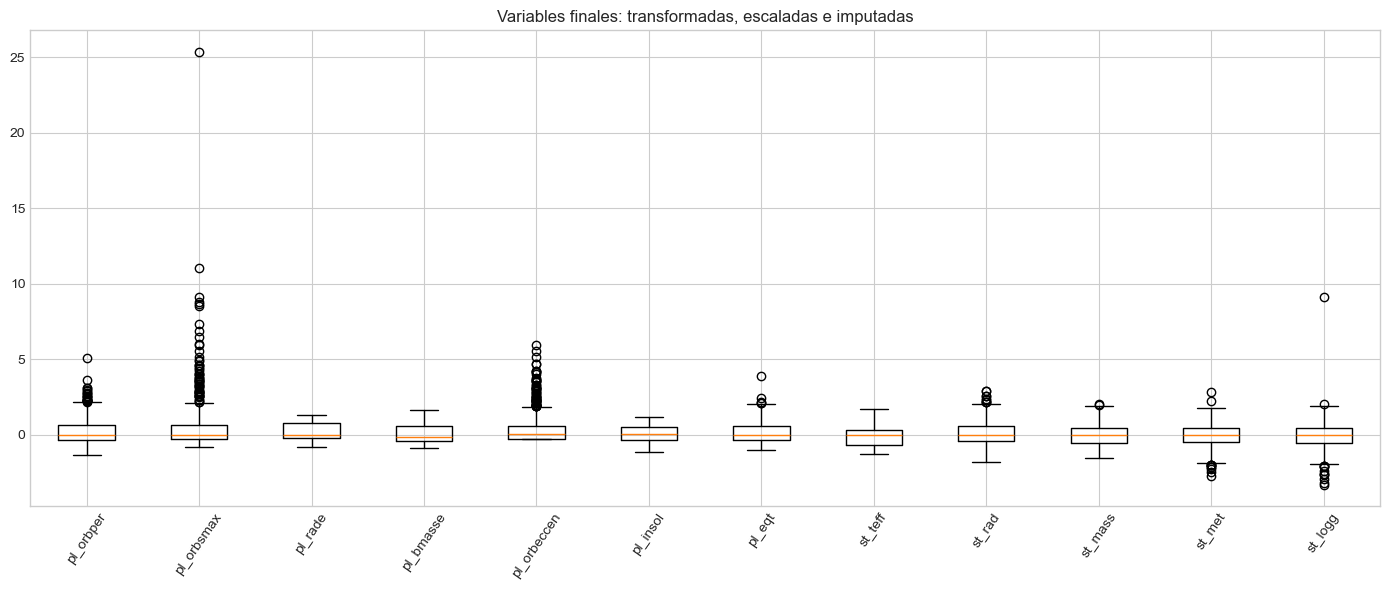

In [16]:
# BLOQUE 14B — Visualizar las distribuciones finales


fig, ax = plt.subplots(figsize=(14, 6))
ax.boxplot(
    [processed_features_df[column] for column in FEATURE_COLUMNS],
    tick_labels=FEATURE_COLUMNS,
    showfliers=True,
)
ax.set_title("Variables finales: transformadas, escaladas e imputadas")
ax.tick_params(axis="x", rotation=55)
fig.tight_layout()
plt.show()

In [17]:
# BLOQUE 14C — Ejecutar las comprobaciones automáticas


assert processed_df[ID_COLUMN].is_unique
assert len(processed_df) == int(retained_mask.sum())
assert processed_df.columns.tolist() == [ID_COLUMN, *FEATURE_COLUMNS]
assert not processed_df[FEATURE_COLUMNS].isna().any().any()
assert np.isfinite(processed_df[FEATURE_COLUMNS].to_numpy()).all()
assert (row_audit.loc[row_audit["retenido"], "variables_presentes"] >= MIN_PRESENT_FEATURES).all()

final_checks = pd.Series(
    {
        "filas_procesadas": len(processed_df),
        "variables_modelo": len(FEATURE_COLUMNS),
        "duplicados": int(processed_df[ID_COLUMN].duplicated().sum()),
        "nulos_finales": int(processed_df[FEATURE_COLUMNS].isna().sum().sum()),
        "no_finitos": int((~np.isfinite(processed_df[FEATURE_COLUMNS].to_numpy())).sum()),
    },
    name="resultado",
)
display(final_checks.to_frame())
print("Comprobaciones finales superadas.")

,resultado
filas_procesadas,731
variables_modelo,12
duplicados,0
nulos_finales,0
no_finitos,0


Comprobaciones finales superadas.


### Conclusión del bloque 14

Las comprobaciones pasan correctamente: **731 filas, 12 variables, 0 nulos, 0 infinitos y 0 identificadores duplicados**. Los valores alejados que aún aparecen en los boxplots son coherentes con la política explícita de conservar outliers.

## Bloque 15. Exportación y entrega


Se exportan el CSV para PCA, los datos originales seleccionados, auditorías, comparaciones, metadata y el pipeline entrenado. Crear las carpetas desde el código permite reproducir el flujo en otro equipo sin preparar directorios manualmente.

In [18]:
# BLOQUE 15A — Guardar datos, auditorías, metadata y pipeline


# 1. Reunimos todas las rutas de salida en un único diccionario.
# Esto evita repetir rutas y facilita recorrerlas al final para informar al usuario.
output_paths = {
    # Dataset principal que utilizará el notebook 04 para realizar PCA.
    "processed_data": PROJECT_ROOT / PROCESSED_DATA_PATH,
    # Copia de las filas retenidas antes de transformar, escalar e imputar.
    "selected_raw_data": PROJECT_ROOT / SELECTED_RAW_DATA_PATH,
    # Auditoría que indica qué planetas se conservaron y cuáles se excluyeron.
    "row_audit": PROJECT_ROOT / ROW_AUDIT_PATH,
    # Resumen por variable de nulos, asimetría y valores extremos.
    "quality_summary": PROJECT_ROOT / QUALITY_SUMMARY_PATH,
    # Tabla utilizada para justificar la elección del escalado robusto.
    "scaler_comparison": PROJECT_ROOT / SCALER_COMPARISON_PATH,
    # Resultados de la prueba de mediana frente a KNN.
    "imputer_comparison": PROJECT_ROOT / IMPUTER_COMPARISON_PATH,
    # Pipeline entrenado, necesario para transformar futuros planetas igual que el dataset.
    "pipeline": PROJECT_ROOT / PIPELINE_PATH,
    # Archivo JSON con el contrato de variables y las decisiones del preprocessing.
    "metadata": PROJECT_ROOT / METADATA_PATH,
}

# 2. Construimos la metadata del proceso.
# La metadata funciona como una ficha técnica: permite saber qué datos, variables,
# parámetros y reglas produjeron el CSV procesado sin tener que leer todo el código.
metadata = {
    # Procedencia del dataset original.
    "source": "NASA Exoplanet Archive - Planetary Systems (PS)",
    "source_url": NASA_SOURCE_URL,
    "input_path": str(RAW_DATA_PATH),
    "output_path": str(PROCESSED_DATA_PATH),

    # Identificador y orden exacto de las variables.
    "id_column": ID_COLUMN,
    "planet_features": PLANET_FEATURES,
    "stellar_features": STELLAR_FEATURES,
    "feature_columns": FEATURE_COLUMNS,

    # Transformaciones aplicadas antes de PCA.
    "log1p_features": LOG1P_FEATURES,
    "linear_features": LINEAR_FEATURES,
    "minimum_present_features": MIN_PRESENT_FEATURES,
    "scaler": SCALER_NAME,

    # Configuración exacta del imputador seleccionado.
    "imputer": {
        "name": "KNNImputer",
        "n_neighbors": KNN_NEIGHBORS,
        "weights": KNN_WEIGHTS,
    },

    # Política aplicada a observaciones extremas: se preservan, no se borran.
    "outlier_policy": "preserve; audit with IQR; mitigate with log1p and robust scaling",

    # Trazabilidad del número de registros antes y después del filtro.
    "rows_raw": int(len(df_raw)),
    "rows_retained": int(len(processed_df)),
    "rows_excluded": int(len(df_raw) - len(processed_df)),

    # Momento exacto de exportación expresado en UTC.
    "exported_at_utc": pd.Timestamp.now(tz="UTC").isoformat(),
}

# 3. Recuperamos el resumen de nulos retenidos si el kernel no lo conserva.
# Normalmente esta tabla ya existe porque se calcula en el bloque 7. La condición
# hace la exportación más robusta cuando esa celda no se ha ejecutado en la sesión.
if "missingness_retained" not in globals():
    missingness_retained = pd.DataFrame(
        {
            "nulos_en_retenidos": df_retained[FEATURE_COLUMNS].isna().sum(),
            "porcentaje_nulos_en_retenidos": (
                df_retained[FEATURE_COLUMNS].isna().mean() * 100
            ),
        }
    ).sort_values("porcentaje_nulos_en_retenidos", ascending=False)

    # Reproducimos también la clasificación de riesgo definida en el bloque 7.
    missingness_retained["nivel_riesgo"] = np.where(
        missingness_retained["porcentaje_nulos_en_retenidos"] >= 40,
        "alto",
        np.where(
            missingness_retained["porcentaje_nulos_en_retenidos"] >= 20,
            "medio",
            "bajo",
        ),
    )

# 4. Unimos los diagnósticos por variable en una sola tabla.
# Todas estas tablas usan el nombre de la variable como índice, por eso join()
# puede alinearlas correctamente sin depender de la posición de sus filas.
quality_summary = (
    missingness_before
    .join(missingness_retained)
    .join(skewness_comparison)
    .join(outlier_summary[["outliers_iqr", "porcentaje_outliers"]])
)

# 5. Exportamos únicamente si el interruptor global está activado.
# Esta condición permite ejecutar el análisis sin sobrescribir artefactos cuando
# EXPORT_ARTIFACTS se establece en False durante una prueba.
if EXPORT_ARTIFACTS:
    # Creamos data/processed si todavía no existe. parents=True crea también
    # directorios intermedios y exist_ok=True evita errores si ya están creados.
    output_paths["processed_data"].parent.mkdir(parents=True, exist_ok=True)

    # Guardamos el dataset final: identificador más las 12 variables procesadas.
    processed_df.to_csv(output_paths["processed_data"], index=False)

    # Guardamos también los valores originales de las mismas filas retenidas.
    # Este archivo permite comparar el antes y el después del pipeline.
    df_retained[[ID_COLUMN, *FEATURE_COLUMNS]].to_csv(
        output_paths["selected_raw_data"], index=False
    )

    # Exportamos las tablas de auditoría y las comparaciones metodológicas.
    row_audit.to_csv(output_paths["row_audit"], index=False)
    quality_summary.to_csv(output_paths["quality_summary"], index_label="variable")
    scaler_comparison.to_csv(output_paths["scaler_comparison"])
    imputer_comparison.to_csv(output_paths["imputer_comparison"])

    # Serializamos el pipeline completo con joblib. No se guarda solo el scaler:
    # se conservan juntas las transformaciones, el escalado y la imputación KNN.
    joblib.dump(preprocessing_pipeline, output_paths["pipeline"])

    # JSON es adecuado para metadata porque es legible por personas y aplicaciones.
    # ensure_ascii=False conserva correctamente tildes y otros caracteres Unicode.
    output_paths["metadata"].write_text(
        json.dumps(metadata, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

    # Mostramos cada artefacto generado y su ruta para facilitar la comprobación.
    print("Artefactos exportados:")
    for name, path in output_paths.items():
        print(f"- {name}: {path}")
else:
    # En modo de prueba se realizan todos los cálculos, pero no se escribe en disco.
    print("Exportación desactivada.")

Artefactos exportados:
- processed_data: D:\HELEN\PERSONAL\FORMACIÓN\++ia_formacion\BOOTCAMP - F5\CURSO\PROYECTO_3.2\exoplanet-profiler\data\processed\exoplanets_preprocessed.csv
- selected_raw_data: D:\HELEN\PERSONAL\FORMACIÓN\++ia_formacion\BOOTCAMP - F5\CURSO\PROYECTO_3.2\exoplanet-profiler\data\processed\exoplanets_selected_raw.csv
- row_audit: D:\HELEN\PERSONAL\FORMACIÓN\++ia_formacion\BOOTCAMP - F5\CURSO\PROYECTO_3.2\exoplanet-profiler\data\processed\preprocessing_row_audit.csv
- quality_summary: D:\HELEN\PERSONAL\FORMACIÓN\++ia_formacion\BOOTCAMP - F5\CURSO\PROYECTO_3.2\exoplanet-profiler\data\processed\preprocessing_quality_summary.csv
- scaler_comparison: D:\HELEN\PERSONAL\FORMACIÓN\++ia_formacion\BOOTCAMP - F5\CURSO\PROYECTO_3.2\exoplanet-profiler\data\processed\preprocessing_scaler_comparison.csv
- imputer_comparison: D:\HELEN\PERSONAL\FORMACIÓN\++ia_formacion\BOOTCAMP - F5\CURSO\PROYECTO_3.2\exoplanet-profiler\data\processed\preprocessing_imputer_comparison.csv
- pipeline: 

In [19]:
# BLOQUE 15B — Mostrar el resumen final de la entrega


final_summary = pd.Series(
    {
        "planetas_originales": len(df_raw),
        "planetas_procesados": len(processed_df),
        "porcentaje_conservado": len(processed_df) / len(df_raw) * 100,
        "variables_finales": len(FEATURE_COLUMNS),
        "variables_log1p": len(LOG1P_FEATURES),
        "scaler": SCALER_NAME,
        "imputer": f"KNN {KNN_NEIGHBORS} vecinos",
        "nulos_finales": int(processed_df[FEATURE_COLUMNS].isna().sum().sum()),
    },
    name="resultado",
)
display(final_summary.to_frame())

,resultado
planetas_originales,910
planetas_procesados,731
porcentaje_conservado,80.32967
variables_finales,12
variables_log1p,6
scaler,robust
imputer,KNN 5 vecinos
nulos_finales,0


### Conclusión del bloque 15 y siguientes pasos

El preprocessing queda listo para `04_pca_and_cluster_profiling.ipynb`. Ese notebook debe cargar `exoplanets_preprocessed.csv`, usar las 12 variables en el mismo orden y mantener `DATA_ALREADY_SCALED = True`.

Limitaciones que deben acompañar cualquier presentación:

- `pl_insol` depende mucho de imputación.
- el filtro conserva pocos registros de 2026;
- KNN puede suavizar casos excepcionales;
- los resultados corresponden a la versión del catálogo descargada y pueden variar si NASA actualiza los registros.